# XGBoost Regressor Notebook (Using CRSP Data)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import mean_absolute_error
import pickle as pkl

In [5]:
NUM_COL = 'true_prc'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'
SPLIT_DATE = "2014-01-01"
START_BALANCE = 1000
EXIT_PROP = 1.0
n_train_tickers= 1000

##### Data Prep

In [6]:
data = pd.read_csv('./data/crsp_dsf.csv')
data[DATE_COL] = data[DATE_COL].astype('datetime64[s]')
data = data.dropna(subset='dlyclose').reset_index(drop=True)
data['dlyvol'] = data['dlyvol'].fillna(0)
data['tot_shares'] = (data['dlycap'] / data['dlyprc']).round(0)
data[NUM_COL] = data['dlyclose'] * data['tot_shares'] / 1000000
data.head()

C:\Users\jgte2\AppData\Local\Temp\ipykernel_21940\2395485418.py:1: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./data/crsp_dsf.csv')


,permno,hdrcusip,permco,siccd,nasdissuno,yyyymmdd,sharetype,securitytype,securitysubtype,usincflg,...,dlymmcnt,dlyprcvol,dlycumfacpr,dlycumfacshr,cusip,ticker,exchangetier,shrout,tot_shares,true_prc
0,10001,36720410,7953,4925,10398,20100104,NS,EQTY,COM,Y,...,NaN,189625.0,1.0,1.0,29269V10,EGAS,NaN,4361,4361.0,0.044700
1,10026,46603210,7976,2052,10433,20100104,NS,EQTY,COM,Y,...,29.0,1923931.8,1.0,1.0,46603210,JJSF,Q,18374,18374.0,0.738635
2,10032,72913210,7980,3672,10437,20100104,NS,EQTY,COM,Y,...,46.0,3580667.5,1.0,1.0,72913210,PLXS,Q,39649,39649.0,1.166077
3,10051,41043F20,7999,4813,10468,20100104,NS,EQTY,COM,Y,...,NaN,1992150.0,1.0,1.0,41043F20,HGR,NaN,31680,31680.0,0.451440
4,10104,68389X10,8045,7379,10536,20100104,NS,EQTY,COM,Y,...,79.0,668947587.0,1.0,1.0,68389X10,ORCL,Q,5011220,5011220.0,124.528817


In [7]:
tickers = data[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True)

training_tickers = tickers.sample(n=n_train_tickers,random_state=29)

training_tickers.to_csv("./data/training_tickers.csv", index=False)

In [ ]:
reg_df = data.sort_values([TICKER_COL1, TICKER_COL2, DATE_COL]).copy()

reg_df["target"] = (reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].shift(-1))

for lag in [1, 2, 3, 5, 10, 20]:
    reg_df[f"lag_prc_{lag}"] = (reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].shift(lag))

for lag in [1, 2, 3, 5, 10]:
    reg_df[f"lag_ret_{lag}"] = (reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyret"].shift(lag))

for win in [5, 10, 20, 50]:
    reg_df[f"ma_{win}"] = (reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].transform(lambda x: x.rolling(win).mean()))

reg_df["vol_20"] = (reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyret"].transform(lambda x: x.rolling(20).std()))

reg_df["vol_ma_20"] = (reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyprcvol"].transform(lambda x: x.rolling(20).mean()))

reg_df["vol_ratio"] = reg_df["dlyprcvol"] / reg_df["vol_ma_20"]

reg_df["spread"] = reg_df["dlyask"] - reg_df["dlybid"]

FEATURES = ["lag_prc_1", "lag_prc_2", "lag_prc_3", "lag_prc_5", "lag_prc_10", "lag_prc_20",
            "lag_ret_1", "lag_ret_2", "lag_ret_3", "lag_ret_5", "lag_ret_10",
            "ma_5", "ma_10", "ma_20", "ma_50", "vol_20", "vol_ratio", "spread", "dlyvol"]

reg_df = reg_df[[TICKER_COL1, TICKER_COL2, DATE_COL, NUM_COL, "target"] + FEATURES].dropna().reset_index(drop=True)

ticker_set = set(map(tuple, training_tickers[[TICKER_COL1, TICKER_COL2]].to_numpy()))

mask = reg_df[[TICKER_COL1, TICKER_COL2]].apply(tuple, axis=1).isin(ticker_set)

train_df = reg_df[mask & (reg_df[DATE_COL] < SPLIT_DATE)]

test_df = reg_df[reg_df[DATE_COL] >= SPLIT_DATE]

X_train = train_df[FEATURES]
y_train = train_df["target"]

X_test = test_df[FEATURES]
y_test = test_df["target"]

reg_df.head()

##### Basline Model

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

with open("./models/baseline_xgboost_reg_model_062126_01.pkl", "wb") as f:
    pkl.dump(model, f)

In [ ]:
preds_df = test_df[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL, "target"]].copy()
preds_df['pred'] = preds

##### Trading Strategy

In [ ]:
def trade_strat_single(df, curr_b=1000, exit_prop=1.0, pred_col='pred'):
    ### Defaults to starting balance of 1000 and full exits
    curr_vol = 0

    returns = []

    for _, row in df.iterrows():

        pred = row[pred_col]
        num = row[NUM_COL]

        ### Buy signal
        if pred >= num:
            ### Only buy if we have balance
            ### Otherwise we will just be holding the stock
            if curr_b > 0:
                curr_vol += curr_b / num
                curr_b = 0

        ### Sell signal
        else:
            ### Only sell if we have volume to sell
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * num
                curr_vol -= shares_sold
                
        ### Current Return of the Strategy
        ### Cash Balance + Value of Held Stock
        returns.append(curr_b + curr_vol * num)
    
    return returns

In [ ]:
def trade_strat(data, tickers, curr_b=START_BALANCE, exit_prop=EXIT_PROP, pred_col='pred'):
    ret_df = pd.DataFrame()
    for t in tickers:
        df = data[(data[TICKER_COL1] == t[0]) & (data[TICKER_COL2] == t[1])].reset_index(drop=True)
        returns = trade_strat_single(df, curr_b=curr_b, exit_prop=exit_prop, pred_col=pred_col)
        start_vol = START_BALANCE / df[NUM_COL].iloc[0]
        hold_ret = start_vol * df[NUM_COL].values
        stg_df = (
            df[[TICKER_COL1, TICKER_COL2, DATE_COL]]
            .copy()
            .assign(
                strat_ret=returns,
                hold_ret=hold_ret
            )
        )
        if len(ret_df) == 0:
            ret_df = stg_df.copy()
        else:
            ret_df = pd.concat([ret_df, stg_df])
    return ret_df

In [ ]:
# pred_tickers = preds_df[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True)
# ret_df = trade_strat(preds_df, pred_tickers.values)
# ret_df.to_csv(f"./data/xgboost_reg_baseline_model_returns_062026_01.csv", index=False)

ret_df = pd.read_csv(f"./data/xgboost_reg_baseline_model_returns_062026_01.csv")
ret_df[DATE_COL] = pd.to_datetime(ret_df[DATE_COL])

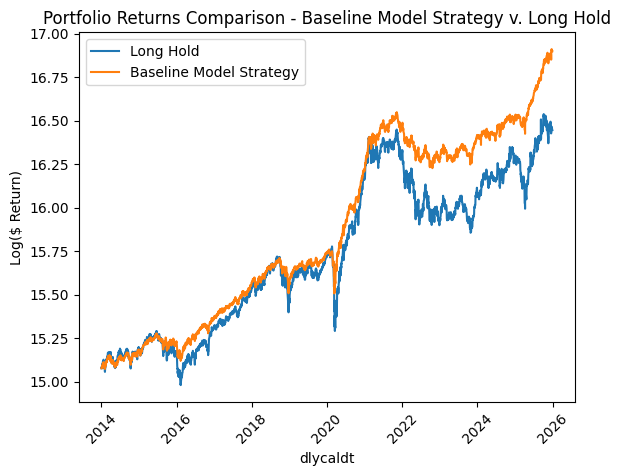

In [ ]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"}).iloc[:-1,:]

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="Baseline Model Strategy")

plt.title("Portfolio Returns Comparison - Baseline Model Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

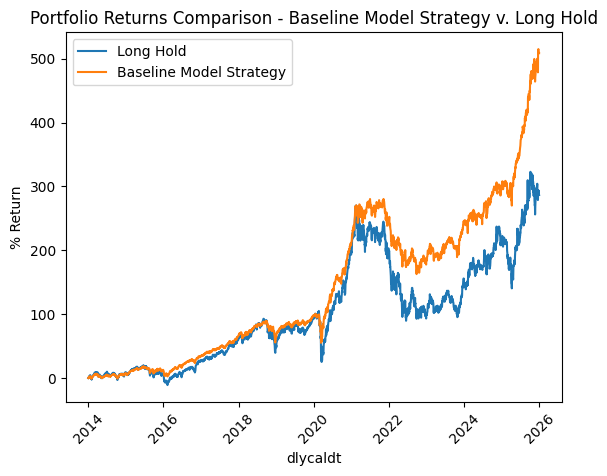

In [ ]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL1 : "count"}).rename(columns={TICKER_COL1:"num_stocks"}).iloc[:-1,:]
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="Baseline Model Strategy")

plt.title("Portfolio Returns Comparison - Baseline Model Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### Model Fine-Tuning

In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }

    model = XGBRegressor(
        **params,
        random_state=0,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return mean_absolute_error(y_test, preds)

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

best_params = study.best_params

[I 2026-06-20 23:24:06,864] A new study created in memory with name: no-name-9db7841d-a201-47b5-8be5-ec75b31d6f5d
[I 2026-06-20 23:24:27,114] Trial 0 finished with value: 2.707027986206818 and parameters: {'n_estimators': 401, 'max_depth': 4, 'learning_rate': 0.024302618401133104, 'subsample': 0.6341343307884704, 'colsample_bytree': 0.7355241218459067, 'min_child_weight': 9}. Best is trial 0 with value: 2.707027986206818.
[I 2026-06-20 23:24:56,561] Trial 1 finished with value: 2.7055801416101875 and parameters: {'n_estimators': 631, 'max_depth': 5, 'learning_rate': 0.011795338927481238, 'subsample': 0.6636933890737168, 'colsample_bytree': 0.7253423433165747, 'min_child_weight': 2}. Best is trial 1 with value: 2.7055801416101875.
[I 2026-06-20 23:25:55,785] Trial 2 finished with value: 2.726791888765149 and parameters: {'n_estimators': 738, 'max_depth': 8, 'learning_rate': 0.08465045879693567, 'subsample': 0.7457856017387615, 'colsample_bytree': 0.7042741590468485, 'min_child_weight': 

In [ ]:
final_model = XGBRegressor(
    **best_params,
    random_state=0,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
final_preds = final_model.predict(X_test)
with open("./models/tuned_xgboost_model_062126_01.pkl", "wb") as f:
    pkl.dump(final_model, f)

In [ ]:
try:
    preds_df['final_pred'] = final_preds
except:
    preds_df = test_df[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL, "target"]].copy()
    preds_df['final_pred'] = final_preds

In [ ]:
# pred_tickers = preds_df[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True)
# ret_df = trade_strat(preds_df, pred_tickers.values, pred_col='final_pred')
# ret_df.to_csv(f"./data/xgboost_reg_tuned_model_returns_062126_01.csv", index=False)

ret_df = pd.read_csv(f"./data/xgboost_reg_tuned_model_returns_062126_01.csv")
ret_df[DATE_COL] = pd.to_datetime(ret_df[DATE_COL])

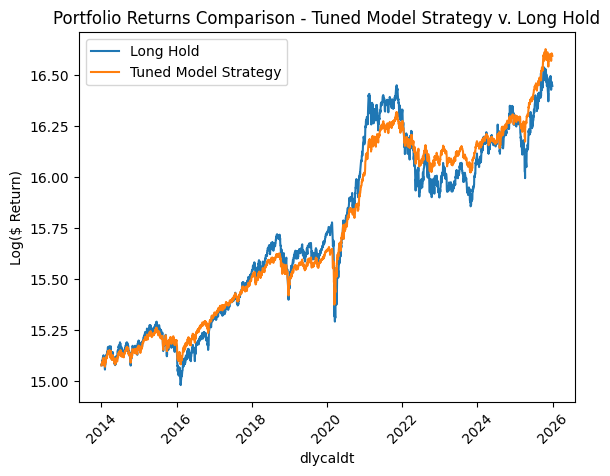

In [ ]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"}).iloc[:-1,:]

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="Tuned Model Strategy")

plt.title("Portfolio Returns Comparison - Tuned Model Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

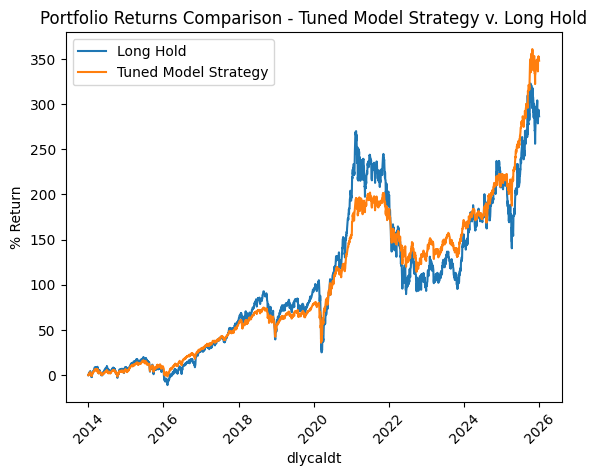

In [ ]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL1 : "count"}).rename(columns={TICKER_COL1:"num_stocks"}).iloc[:-1,:]
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="Tuned Model Strategy")

plt.title("Portfolio Returns Comparison - Tuned Model Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()